In [4]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'archive.zip', 'array', 'matchcase practice.py', 'netflix_analysis.ipynb', 'practice.py', 'project', 'Untitled.ipynb']


In [3]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall()

print(os.listdir())

['.ipynb_checkpoints', 'archive.zip', 'array', 'matchcase practice.py', 'netflix_analysis.ipynb', 'netflix_titles.csv', 'practice.py', 'project', 'Untitled.ipynb']


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [9]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [10]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [11]:
import sqlite3

conn = sqlite3.connect('netflix.db')
df.to_sql('netflix', conn, if_exists='replace', index=False)

8790

In [12]:
query = "SELECT * FROM netflix LIMIT 5"
result = pd.read_sql(query, conn)
result

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
query1 = """
SELECT type, COUNT(*) as count
FROM netflix
GROUP BY type
"""
pd.read_sql(query1, conn)

,type,count
0,Movie,6126
1,TV Show,2664


In [14]:
query2 = """
SELECT country, COUNT(*) as count
FROM netflix
WHERE country != 'Unknown'
GROUP BY country
ORDER BY count DESC
LIMIT 10
"""
pd.read_sql(query2, conn)

,country,count
0,United States,2809
1,India,972
2,United Kingdom,418
3,Japan,243
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [15]:
query3 = """
SELECT release_year, COUNT(*) as count
FROM netflix
GROUP BY release_year
ORDER BY release_year DESC
LIMIT 10
"""
pd.read_sql(query3, conn)

,release_year,count
0,2021,592
1,2020,953
2,2019,1030
3,2018,1146
4,2017,1030
5,2016,901
6,2015,555
7,2014,352
8,2013,286
9,2012,236


In [16]:
query4 = """
SELECT rating, COUNT(*) as count
FROM netflix
GROUP BY rating
ORDER BY count DESC
"""
pd.read_sql(query4, conn)

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [17]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


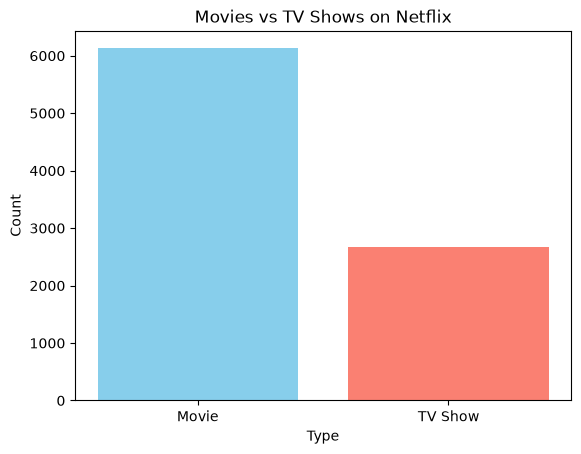

In [18]:
result1 = pd.read_sql(query1, conn)
plt.bar(result1['type'], result1['count'], color=['skyblue', 'salmon'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

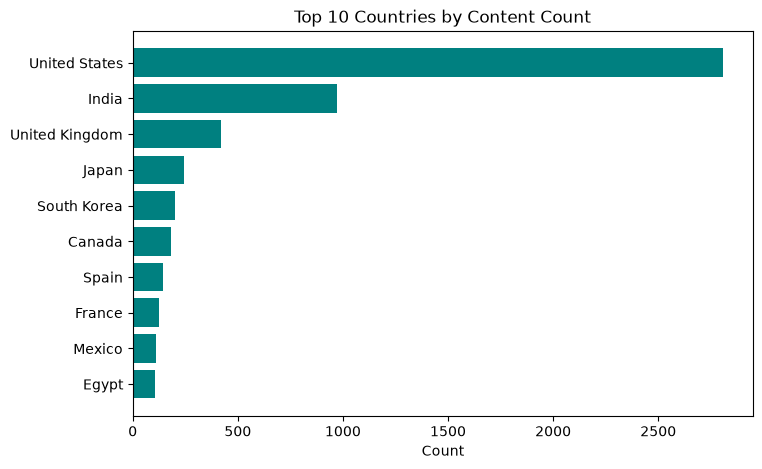

In [19]:
result2 = pd.read_sql(query2, conn)
plt.figure(figsize=(8,5))
plt.barh(result2['country'], result2['count'], color='teal')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.gca().invert_yaxis()  # highest at top
plt.show()

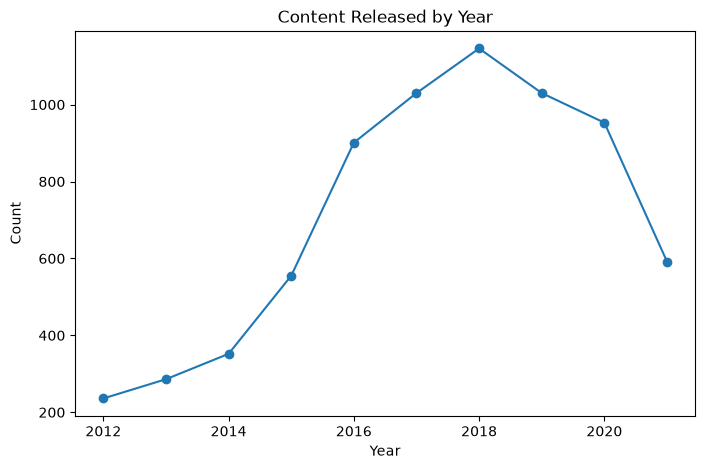

In [22]:
result3 = pd.read_sql(query3, conn)
plt.figure(figsize=(8,5))
plt.plot(result3['release_year'], result3['count'], marker='o')
plt.title('Content Released by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

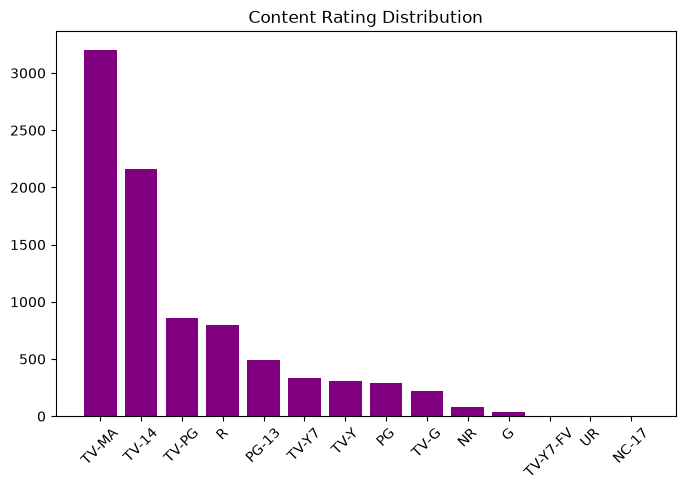

In [23]:
result4 = pd.read_sql(query4, conn)
plt.figure(figsize=(8,5))
plt.bar(result4['rating'], result4['count'], color='purple')
plt.title('Content Rating Distribution')
plt.xticks(rotation=45)
plt.show()

In [24]:
result3.sort_values('count', ascending=False).head(3)
result3.sort_values('count', ascending=True).head(3)

,release_year,count
9,2012,236
8,2013,286
7,2014,352


In [25]:
result4.sort_values('count', ascending=True).head(5)

,rating,count
12,UR,3
13,NC-17,3
11,TV-Y7-FV,6
10,G,41
9,NR,79


In [26]:
result1

,type,count
0,Movie,6126
1,TV Show,2664
